In [2]:
import pickle
import numpy as np 
import pandas as pd

Loading the dataset created during preprocessing 

In [3]:
loan_data_train_input = pd.read_csv('loan_data_inputs_train.csv',index_col=0)
loan_data_train_target = pd.read_csv('loan_data_targets_train.csv',index_col = 0)
loan_data_test_input = pd.read_csv('loan_data_inputs_test.csv',index_col = 0)
loan_data_test_target = pd.read_csv('loan_data_targets_test.csv',index_col = 0)

In [4]:
loan_data_test_input.shape

(93257, 317)

In [5]:
loan_data_train_input.shape

(373028, 317)

## Selecting the cat features

In [6]:
inputs_train_with_ref_cat = loan_data_train_input.loc[: , ['grade:A',
'grade:B',
'grade:C',
'grade:D',
'grade:E',
'grade:F',
'grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'home_ownership:OWN',
'home_ownership:MORTGAGE',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'addr_state:NM_VA',
'addr_state:NY',
'addr_state:OK_TN_MO_LA_MD_NC',
'addr_state:CA',
'addr_state:UT_KY_AZ_NJ',
'addr_state:AR_MI_PA_OH_MN',
'addr_state:RI_MA_DE_SD_IN',
'addr_state:GA_WA_OR',
'addr_state:WI_MT',
'addr_state:TX',
'addr_state:IL_CT',
'addr_state:KS_SC_CO_VT_AK_MS',
'addr_state:WV_NH_WY_DC_ME_ID',
'verification_status:Not Verified',
'verification_status:Source Verified',
'verification_status:Verified',
'purpose:smallBus_edu_moving_house',
'purpose:other_renewable_medical_wedding',
'purpose:wedding_vacation',
'purpose:homeImprovement_majorPurchase_car',
'purpose:credit_card',
'initial_list_status:f',
'initial_list_status:w',
'term_int:36',
'term_int:60',
'emp_length:0',
'emp_length:1',
'emp_length:2-4',
'emp_length:5-6',
'emp_length:7-9',
'emp_length:10',
'mnths_since_issue_d_date:<39',
'mnths_since_issue_d_date:39-41',
'mnths_since_issue_d_date:42-42',
'mnths_since_issue_d_date:43-50',
'mnths_since_issue_d_date:51-53',
'mnths_since_issue_d_date:54-64',
'mnths_since_issue_d_date:65-84',
'mnths_since_issue_d_date:>84',
'int_rate:<9.548',
'int_rate:9.548-12.025',
'int_rate:12.025-15.74',
'int_rate:15.74-20.281',
'int_rate:>20.281',
'mnths_since_earlier_cr_line:<143',
'mnths_since_earlier_cr_line:144-167',
'mnths_since_earlier_cr_line:168-250',
'mnths_since_earlier_cr_line:251-274',
'mnths_since_earlier_cr_line:>275',
'delinq_2yrs:0',
'delinq_2yrs:1-3',
'delinq_2yrs:>=4',
'inq_last_6mths:0',
'inq_last_6mths:1-2',
'inq_last_6mths:3-6',
'inq_last_6mths:>6',
'open_acc:0',
'open_acc:1-3',
'open_acc:4-12',
'open_acc:13-22',
'open_acc:>=23',
'pub_rec:0-2',
'pub_rec:3-4',
'pub_rec:>=5',
'total_acc:<=27',
'total_acc:28-51',
'total_acc:>=52',
'acc_now_delinq:0',
'acc_now_delinq:>=1',
'total_rev_hi_lim:<=5K',
'total_rev_hi_lim:5K-10K',
'total_rev_hi_lim:10K-20K',
'total_rev_hi_lim:20K-30K',
'total_rev_hi_lim:30K-40K',
'total_rev_hi_lim:40K-55K',
'total_rev_hi_lim:55K-95K',
'total_rev_hi_lim:>95K',
'annual_inc:<20k',
'annual_inc:20k-30k',
'annual_inc:30k-40k',
'annual_inc:40k-50k',
'annual_inc:50k-60k',
'annual_inc:60k-70k',
'annual_inc:70k-80k',
'annual_inc:80k-90k',
'annual_inc:90k-100k',
'annual_inc:100k-120k',
'annual_inc:120k-140k',
'annual_inc:>140k',
'dti:<=1.6',
'dti:1.6-4',
'dti:4-5.6',
'dti:5.6-8',
'dti:8-15.2',
'dti:15.2-16.8',
'dti:16.8-20.8',
'dti:>20.8',
'mths_since_last_deling:Missing',
'mths_since_last_delinq:0-3',
'mths_since_last_delinq:4-30',
'mths_since_last_delinq:31-56',
'mths_since_last_delinq:>=57',
'mths_since_last_record:Missing',
'mths_since_last_record:0-2',
'mths_since_last_record:3-20',
'mths_since_last_record:21-31',
'mths_since_last_record:32-80',
'mths_since_last_record:81-86',
'mths_since_last_record:>86',
]]

these are the ref categories I chose randomly to remove because if we have 6 dummy variables we dont need all 6 just 5 is required

In [7]:
ref_categories = ['grade:G',
'home_ownership:RENT_OTHER_NONE_ANY',
'addr_state:ND_NE_IA_NV_FL_HI_AL',
'verification_status:Verified',
'purpose:smallBus_edu_moving_house',
'initial_list_status:f',
'term_int:60',
'emp_length:0',
'mnths_since_issue_d_date:>84',
'int_rate:>20.281',
'mnths_since_earlier_cr_line:<143',
'delinq_2yrs:>=4',
'inq_last_6mths:>6',
'open_acc:0',
'pub_rec:0-2',
'total_acc:<=27',
'acc_now_delinq:0',
'total_rev_hi_lim:<=5K',
'annual_inc:<20k',
'dti:>20.8',
'mths_since_last_delinq:0-3',
'mths_since_last_record:0-2']

In [8]:
inputs_train = inputs_train_with_ref_cat.drop(ref_categories, axis = 1)
# From the dataframe with input variables, we drop the variables with variable names in the list with reference categories. 
inputs_train.head()

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,...,mths_since_last_deling:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,mths_since_last_record:Missing,mths_since_last_record:3-20,mths_since_last_record:21-31,mths_since_last_record:32-80,mths_since_last_record:81-86,mths_since_last_record:>86
427211,True,False,False,False,False,False,False,True,0,False,...,1,0,0,0,1,0,0,0,0,0
206088,False,False,True,False,False,False,False,True,0,False,...,0,1,0,0,1,0,0,0,0,0
136020,True,False,False,False,False,False,False,True,0,False,...,0,0,1,0,1,0,0,0,0,0
412305,False,False,False,True,False,False,False,False,0,False,...,0,1,0,0,1,0,0,0,0,0
36159,False,False,True,False,False,False,False,True,0,False,...,1,0,0,0,1,0,0,0,0,0


In [9]:
inputs_train.shape

(373028, 98)

In [10]:
loan_data_train_target.shape

(373028, 1)

## Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

first attempt normal logistic model

In [12]:
model = LogisticRegression()


In [13]:
model.fit(inputs_train,loan_data_train_target)

c:\Users\TransOrg\OneDrive\Documents\Credit Risk Modelling\CRM-Classical\Code\newenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
model.intercept_

array([-0.23724875])

In [15]:
model.coef_

array([[ 0.92060385,  0.69792428,  0.5005366 ,  0.31851484,  0.16334928,
        -0.02224962,  0.08979087,  0.10817185,  0.05046107,  0.0742707 ,
         0.07068202,  0.0788829 ,  0.09273874,  0.146008  ,  0.11336537,
         0.1982908 ,  0.24406322,  0.23943157,  0.27825209,  0.34493198,
         0.53888868,  0.09076548, -0.00875702,  0.0349181 ,  0.28164904,
         0.10187736,  0.12068948,  0.05371207,  0.06139913,  0.09516848,
         0.12618931,  0.09335397,  0.06495309,  0.12806255,  1.14088282,
         0.92355467,  0.81231233,  0.62689082,  0.48208227,  0.24932957,
        -0.01571842,  0.96035279,  0.61733953,  0.36773381,  0.15455568,
         0.06545782,  0.05576321,  0.09679471,  0.14052467, -0.09055708,
        -0.11569409,  0.28887417,  0.14671687, -0.05897383,  0.02049648,
        -0.0509797 , -0.07789925, -0.07941157,  0.13165683,  0.07197522,
        -0.02395796,  0.03876577,  0.15116295,  0.07301552,  0.03778461,
         0.03372932,  0.03938009,  0.06721437,  0.0

In [16]:
feature_names = inputs_train.columns.values

In [17]:
len(feature_names)

98

created a summary table for better understanding of coefficient for every feature (here feature means all the dummy variables I created)

In [18]:
summary_table = pd.DataFrame(columns=['feature_names'],data = feature_names)

In [19]:
summary_table['Coefficients'] = np.transpose(model.coef_)

In [20]:
summary_table

,feature_names,Coefficients
0,grade:A,0.920604
1,grade:B,0.697924
2,grade:C,0.500537
3,grade:D,0.318515
4,grade:E,0.163349
...,...,...
93,mths_since_last_record:3-20,0.211600
94,mths_since_last_record:21-31,0.160262
95,mths_since_last_record:32-80,0.304535
96,mths_since_last_record:81-86,-0.037147


In [21]:
summary_table.index = summary_table.index + 1

In [22]:
summary_table.loc[0]= ['Intercept',model.intercept_[0]]

In [23]:
summary_table = summary_table.sort_index()

In [24]:
summary_table

,feature_names,Coefficients
0,Intercept,-0.237249
1,grade:A,0.920604
2,grade:B,0.697924
3,grade:C,0.500537
4,grade:D,0.318515
...,...,...
94,mths_since_last_record:3-20,0.211600
95,mths_since_last_record:21-31,0.160262
96,mths_since_last_record:32-80,0.304535
97,mths_since_last_record:81-86,-0.037147


## with P values 

to check the statistical significance of every coefficient we need to calculate the p_values and my null hypothesis in this case is that the feature has no impact on predicting the Probability of default(PD) so if I have a coefficient having p_value > 0.05 ( this is the normal chosen significance value) that means that this particular feature has no imact on predicting the PD thus I will try to remove that feature

In [25]:
from sklearn import linear_model
import scipy.stats as stat

class LogisticRegression_with_p_values:
    
    def __init__(self,*args,**kwargs):#,**kwargs):
        self.model = linear_model.LogisticRegression(*args,**kwargs)#,**args)

    def fit(self,X,y):
        self.model.fit(X,y)
        
        #### Get p-values for the fitted model ####
        denom = (2.0 * (1.0 + np.cosh(self.model.decision_function(X))))
        denom = np.tile(denom,(X.shape[1],1)).T
        F_ij = np.dot((X / denom).T,X) ## Fisher Information Matrix
        Cramer_Rao = np.linalg.inv(F_ij) ## Inverse Information Matrix
        sigma_estimates = np.sqrt(np.diagonal(Cramer_Rao))
        z_scores = self.model.coef_[0] / sigma_estimates # z-score for eaach model coefficient
        p_values = [stat.norm.sf(abs(x)) * 2 for x in z_scores] ### two tailed test for p-values
        
        self.coef_ = self.model.coef_
        self.intercept_ = self.model.intercept_
        self.p_values = p_values

In [26]:
model = LogisticRegression_with_p_values()


In [27]:
inputs_train = inputs_train.astype(int)


In [28]:
model.fit(inputs_train,loan_data_train_target)

c:\Users\TransOrg\OneDrive\Documents\Credit Risk Modelling\CRM-Classical\Code\newenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
p_values = model.p_values

In [30]:
p_values = np.append(np.nan,np.array(p_values))

In [31]:
p_values

array([            nan, 1.25540386e-023, 3.95479358e-029, 6.01876472e-018,
       8.14076781e-009, 1.00996334e-003, 6.66907414e-001, 8.67523487e-006,
       1.51340098e-017, 1.15133277e-001, 2.20089510e-003, 2.28158035e-003,
       1.98452070e-004, 1.99001150e-004, 9.29226653e-011, 1.44835755e-004,
       1.08240615e-013, 2.74712914e-007, 3.26894602e-020, 1.83796549e-021,
       7.16333505e-029, 4.72117331e-024, 6.25849621e-010, 5.15395424e-001,
       1.02561875e-001, 4.90102543e-008, 8.40543886e-007, 6.28288283e-017,
       3.91678661e-005, 1.41450362e-005, 2.42328914e-004, 2.34481396e-011,
       1.29357126e-005, 1.78896338e-003, 3.76388919e-012, 3.60999421e-201,
       1.74782296e-185, 4.23134441e-112, 4.83546062e-105, 5.08768777e-050,
       2.45582537e-017, 5.77513573e-001, 3.97702457e-036, 3.47977339e-043,
       2.20817078e-023, 1.14694641e-007, 8.18846125e-003, 5.00841827e-003,
       1.92921791e-004, 2.58280052e-010, 1.29023471e-001, 4.04918542e-002,
       1.91168225e-002, 2

here I have added the p_value in summary table itself so now every feature has their coefficient listed with their p_values

In [32]:
summary_table['p_value'] = p_values

In [33]:
pd.set_option('display.max_columns', None)

In [34]:
summary_table

,feature_names,Coefficients,p_value
0,Intercept,-0.237249,NaN
1,grade:A,0.920604,1.255404e-23
2,grade:B,0.697924,3.954794e-29
3,grade:C,0.500537,6.018765e-18
4,grade:D,0.318515,8.140768e-09
...,...,...,...
94,mths_since_last_record:3-20,0.211600,1.020599e-01
95,mths_since_last_record:21-31,0.160262,1.806663e-01
96,mths_since_last_record:32-80,0.304535,1.176719e-03
97,mths_since_last_record:81-86,-0.037147,7.336218e-01


now there was a problem that if I have a dummy variable(dv1) which is a feature in our case has p_value >0.05 and an other dummy variable(dv2) has p_value <0.05 but these both dummy variable comes under the same category so instead of removing dv1 I will keep it because removing just one dummy variable doesn't make sense either I have to remove the whole category or not so I will keep it because in the category there are dummy variable which has impact on predicting the PD. but again there is a case lets say if one category has 5 dummy variable and 3 or 4 of them are statistically insignificant so its better to remove the whole category instead of keeping it for one dummy variable

In [35]:
inputs_train = loan_data_train_input.loc[:,['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
                                                        'home_ownership:OWN', 'home_ownership:MORTGAGE', 'addr_state:NM_VA', 
                                                        'addr_state:NY', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:CA',
                                                        'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 
                                                        'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:TX', 'addr_state:IL_CT', 
                                                        'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID',
                                                        'verification_status:Not Verified', 'verification_status:Source Verified', 
                                                        'purpose:other_renewable_medical_wedding', 'purpose:wedding_vacation', 
                                                        'purpose:homeImprovement_majorPurchase_car', 'purpose:credit_card', 
                                                        'initial_list_status:w', 'term_int:36', 'emp_length:1', 'emp_length:2-4', 
                                                        'emp_length:5-6', 'emp_length:7-9', 'emp_length:10', 
                                                        'mnths_since_issue_d_date:<39', 'mnths_since_issue_d_date:39-41', 
                                                        'mnths_since_issue_d_date:42-42', 'mnths_since_issue_d_date:43-50', 
                                                        'mnths_since_issue_d_date:51-53', 'mnths_since_issue_d_date:54-64', 
                                                        'mnths_since_issue_d_date:65-84', 'int_rate:<9.548', 'int_rate:9.548-12.025',
                                                        'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'mnths_since_earlier_cr_line:144-167', 
                                                        'mnths_since_earlier_cr_line:168-250', 'mnths_since_earlier_cr_line:251-274',
                                                        'mnths_since_earlier_cr_line:>275', 'delinq_2yrs:0', 'delinq_2yrs:1-3', 'inq_last_6mths:0',
                                                        'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'total_rev_hi_lim:5K-10K',
                                                        'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 
                                                        'total_rev_hi_lim:40K-55K', 'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K', 
                                                        'annual_inc:20k-30k', 'annual_inc:30k-40k', 'annual_inc:40k-50k', 'annual_inc:50k-60k',
                                                        'annual_inc:60k-70k', 'annual_inc:70k-80k', 'annual_inc:80k-90k', 'annual_inc:90k-100k',
                                                        'annual_inc:100k-120k', 'annual_inc:120k-140k', 'annual_inc:>140k', 'dti:<=1.6',
                                                        'dti:1.6-4', 'dti:4-5.6', 'dti:5.6-8', 'dti:8-15.2', 'dti:15.2-16.8', 'dti:16.8-20.8',
                                                        'mths_since_last_deling:Missing', 'mths_since_last_delinq:4-30', 
                                                        'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57'
]]

In [36]:
inputs_train.shape

(373028, 83)

above are the final features that are selected for final training

In [37]:
pd.reset_option("display.max_rows")

In [38]:

# From the dataframe with input variables, we drop the variables with variable names in the list with reference categories. 
inputs_train

,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,purpose:other_renewable_medical_wedding,purpose:wedding_vacation,purpose:homeImprovement_majorPurchase_car,purpose:credit_card,initial_list_status:w,term_int:36,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mnths_since_issue_d_date:<39,mnths_since_issue_d_date:39-41,mnths_since_issue_d_date:42-42,mnths_since_issue_d_date:43-50,mnths_since_issue_d_date:51-53,mnths_since_issue_d_date:54-64,mnths_since_issue_d_date:65-84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,mnths_since_earlier_cr_line:144-167,mnths_since_earlier_cr_line:168-250,mnths_since_earlier_cr_line:251-274,mnths_since_earlier_cr_line:>275,delinq_2yrs:0,delinq_2yrs:1-3,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,total_rev_hi_lim:5K-10K,total_rev_hi_lim:10K-20K,total_rev_hi_lim:20K-30K,total_rev_hi_lim:30K-40K,total_rev_hi_lim:40K-55K,total_rev_hi_lim:55K-95K,total_rev_hi_lim:>95K,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.6,dti:1.6-4,dti:4-5.6,dti:5.6-8,dti:8-15.2,dti:15.2-16.8,dti:16.8-20.8,mths_since_last_deling:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57
427211,True,False,False,False,False,False,False,True,0,False,0,False,0,0,0,0,0,False,0,1,0,False,True,0,0,0,False,False,1,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
206088,False,False,True,False,False,False,False,True,0,False,0,False,1,0,0,0,0,False,0,0,0,True,False,0,0,0,False,False,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0
136020,True,False,False,False,False,False,False,True,0,False,0,False,0,0,0,1,0,False,0,0,0,False,False,0,0,0,False,False,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
412305,False,False,False,True,False,False,False,False,0,False,0,False,0,0,1,0,0,False,0,0,0,False,True,0,0,0,False,False,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
36159,False,False,True,False,False,False,False,True,0,False,0,True,0,0,0,0,0,False,0,0,0,False,False,0,0,0,False,False,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
259178,False,True,False,False,False,False,False,True,0,False,0,False,1,0,0,0,0,False,0,0,0,True,False,0,0,0,False,True,1,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
365838,False,True,False,False,False,False,False,False,0,True,0,False,0,0,0,0,0,False,0,0,0,False,True,0,0,0,False,False,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
131932,False,True,False,False,False,False,False,False,0,False,0,False,1,0,0,0,0,False,0,0,0,True,False,0,0,0,True,False,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0
146867,False,True,False,False,False,False,False,True,0

In [39]:
inputs_train = inputs_train.astype(int)

In [40]:
inputs_train.to_csv('inputs_train.csv')

fiting a new model named as model2

In [41]:
model2 = LogisticRegression_with_p_values()
model2.fit(inputs_train,loan_data_train_target)

c:\Users\TransOrg\OneDrive\Documents\Credit Risk Modelling\CRM-Classical\Code\newenv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [42]:
feature_names = inputs_train.columns.values

In [43]:
summary_table = pd.DataFrame(columns=['feature_names'],data = feature_names)

In [44]:
summary_table['Coefficients'] = np.transpose(model2.coef_)
summary_table.index = summary_table.index + 1
summary_table.loc[0]= ['Intercept',model.intercept_[0]]
summary_table = summary_table.sort_index()
summary_table

,feature_names,Coefficients
0,Intercept,-0.237249
1,grade:A,1.014864
2,grade:B,0.817441
3,grade:C,0.628211
4,grade:D,0.447463
...,...,...
79,dti:16.8-20.8,0.074222
80,mths_since_last_deling:Missing,0.080606
81,mths_since_last_delinq:4-30,0.128574
82,mths_since_last_delinq:31-56,0.158389


In [45]:
p_values = model2.p_values

In [46]:
p_values = np.append(np.nan,p_values)

In [47]:
summary_table['p_values'] = p_values

In [48]:
summary_table

,feature_names,Coefficients,p_values
0,Intercept,-0.237249,NaN
1,grade:A,1.014864,1.206880e-28
2,grade:B,0.817441,2.909017e-41
3,grade:C,0.628211,7.071104e-29
4,grade:D,0.447463,5.534890e-17
...,...,...,...
79,dti:16.8-20.8,0.074222,1.663392e-06
80,mths_since_last_deling:Missing,0.080606,9.466585e-02
81,mths_since_last_delinq:4-30,0.128574,3.202718e-03
82,mths_since_last_delinq:31-56,0.158389,1.465348e-03


again I created the summary table for updated inputs_train for better understanding

In [49]:
pd.reset_option('display.max_rows',None)

## PD Model Validation


In [50]:
loan_data_test_input.shape

(93257, 317)

to test the model I need to have the same feature in the testing dataset also

In [51]:
inputs_test = loan_data_test_input.loc[:,['grade:A', 'grade:B', 'grade:C', 'grade:D', 'grade:E', 'grade:F',
                                                        'home_ownership:OWN', 'home_ownership:MORTGAGE', 'addr_state:NM_VA', 
                                                        'addr_state:NY', 'addr_state:OK_TN_MO_LA_MD_NC', 'addr_state:CA',
                                                        'addr_state:UT_KY_AZ_NJ', 'addr_state:AR_MI_PA_OH_MN', 'addr_state:RI_MA_DE_SD_IN', 
                                                        'addr_state:GA_WA_OR', 'addr_state:WI_MT', 'addr_state:TX', 'addr_state:IL_CT', 
                                                        'addr_state:KS_SC_CO_VT_AK_MS', 'addr_state:WV_NH_WY_DC_ME_ID',
                                                        'verification_status:Not Verified', 'verification_status:Source Verified', 
                                                        'purpose:other_renewable_medical_wedding', 'purpose:wedding_vacation', 
                                                        'purpose:homeImprovement_majorPurchase_car', 'purpose:credit_card', 
                                                        'initial_list_status:w', 'term_int:36', 'emp_length:1', 'emp_length:2-4', 
                                                        'emp_length:5-6', 'emp_length:7-9', 'emp_length:10', 
                                                        'mnths_since_issue_d_date:<39', 'mnths_since_issue_d_date:39-41', 
                                                        'mnths_since_issue_d_date:42-42', 'mnths_since_issue_d_date:43-50', 
                                                        'mnths_since_issue_d_date:51-53', 'mnths_since_issue_d_date:54-64', 
                                                        'mnths_since_issue_d_date:65-84', 'int_rate:<9.548', 'int_rate:9.548-12.025',
                                                        'int_rate:12.025-15.74', 'int_rate:15.74-20.281', 'mnths_since_earlier_cr_line:144-167', 
                                                        'mnths_since_earlier_cr_line:168-250', 'mnths_since_earlier_cr_line:251-274',
                                                        'mnths_since_earlier_cr_line:>275', 'delinq_2yrs:0', 'delinq_2yrs:1-3', 'inq_last_6mths:0',
                                                        'inq_last_6mths:1-2', 'inq_last_6mths:3-6', 'total_rev_hi_lim:5K-10K',
                                                        'total_rev_hi_lim:10K-20K', 'total_rev_hi_lim:20K-30K', 'total_rev_hi_lim:30K-40K', 
                                                        'total_rev_hi_lim:40K-55K', 'total_rev_hi_lim:55K-95K', 'total_rev_hi_lim:>95K', 
                                                        'annual_inc:20k-30k', 'annual_inc:30k-40k', 'annual_inc:40k-50k', 'annual_inc:50k-60k',
                                                        'annual_inc:60k-70k', 'annual_inc:70k-80k', 'annual_inc:80k-90k', 'annual_inc:90k-100k',
                                                        'annual_inc:100k-120k', 'annual_inc:120k-140k', 'annual_inc:>140k', 'dti:<=1.6',
                                                        'dti:1.6-4', 'dti:4-5.6', 'dti:5.6-8', 'dti:8-15.2', 'dti:15.2-16.8', 'dti:16.8-20.8',
                                                        'mths_since_last_deling:Missing', 'mths_since_last_delinq:4-30', 
                                                        'mths_since_last_delinq:31-56', 'mths_since_last_delinq:>=57'
]]

In [52]:
inputs_test.to_csv('inputs_test.csv')

In [53]:
inputs_train.shape

(373028, 83)

In [54]:
y_hat_test = model2.model.predict(inputs_test)

In [55]:
y_hat_test.sum()

np.int64(93254)

In [56]:
y_hat_test_proba = model2.model.predict_proba(inputs_test)

In [57]:
y_hat_test_proba

array([[0.08095626, 0.91904374],
       [0.1538546 , 0.8461454 ],
       [0.12099076, 0.87900924],
       ...,
       [0.0251398 , 0.9748602 ],
       [0.03983965, 0.96016035],
       [0.04868494, 0.95131506]], shape=(93257, 2))

In [58]:
y_hat_test_proba[:][:,1]

array([0.91904374, 0.8461454 , 0.87900924, ..., 0.9748602 , 0.96016035,
       0.95131506], shape=(93257,))

In [59]:
y_hat_test_proba = y_hat_test_proba[:][:,1]

In [60]:
y_hat_test_proba

array([0.91904374, 0.8461454 , 0.87900924, ..., 0.9748602 , 0.96016035,
       0.95131506], shape=(93257,))

In [61]:
loan_data_test_target_temp = loan_data_test_target

In [62]:
loan_data_test_target_temp.reset_index(drop = True,inplace = True)
loan_data_test_target_temp

,good_bad
0,1
1,1
2,1
3,1
4,1
...,...
93252,1
93253,1
93254,0
93255,1


In [63]:
df_actual_predicted_probs = pd.concat([loan_data_test_target_temp,pd.DataFrame(y_hat_test_proba)],axis = 1)

In [64]:
df_actual_predicted_probs.columns = ['loan_data_target_test','y_hat_test_proba']

here we can see the comparison between actual values and predicted values for test data set

In [65]:
df_actual_predicted_probs.index = loan_data_test_input.index
df_actual_predicted_probs

,loan_data_target_test,y_hat_test_proba
362514,1,0.919044
288564,1,0.846145
213591,1,0.879009
263083,1,0.941012
165001,1,0.968035
...,...,...
115,1,0.871092
296284,1,0.965737
61777,0,0.974860
91763,1,0.960160


## Accuracy and AUC - ROC

AUC -ROC  is needed for deciding the thresholds that we need to accept or reject a particular borrower in credit risk more AUC(Area under the curve) of ROC(Receiver Operating Characteristic) more better the model is performing and in ROC curve every point is representing a different threshold and according to our situdation we can choose which point we should choose

In [66]:
tr = 0.8
df_actual_predicted_probs['y_hat_test'] = np.where(df_actual_predicted_probs['y_hat_test_proba']>tr,1,0)

this is a test we can set any value of tr(threshold) 

In [67]:
df_actual_predicted_probs


,loan_data_target_test,y_hat_test_proba,y_hat_test
362514,1,0.919044,1
288564,1,0.846145,1
213591,1,0.879009,1
263083,1,0.941012,1
165001,1,0.968035,1
...,...,...,...
115,1,0.871092,1
296284,1,0.965737,1
61777,0,0.974860,1
91763,1,0.960160,1


according to the threshold value this is our confusion matrix

In [71]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'],df_actual_predicted_probs['y_hat_test'],rownames=['Predicted'],colnames=['Actual'])

Actual,0,1
Predicted,,
0,2645,7545
1,7822,75245


In [72]:
pd.crosstab(df_actual_predicted_probs['loan_data_target_test'],df_actual_predicted_probs['y_hat_test'],rownames=['Predicted'],colnames=['Actual'])/df_actual_predicted_probs.shape[0]

Actual,0,1
Predicted,,
0,0.028362,0.080905
1,0.083876,0.806856


In [73]:

(pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[0, 0] + (pd.crosstab(df_actual_predicted_probs['loan_data_target_test'], df_actual_predicted_probs['y_hat_test'], rownames = ['Actual'], colnames = ['Predicted']) / df_actual_predicted_probs.shape[0]).iloc[1, 1]
# Here we calculate Accuracy of the model

np.float64(0.8352188039503737)

In [74]:
from sklearn.metrics import roc_auc_score,roc_curve

using roc_curve we get three values fpr,tpr,thresholds. Actually roc is a plot between tpr(as x_axis) and fpr(as y_axis)

In [75]:
roc_curve(df_actual_predicted_probs['loan_data_target_test'],df_actual_predicted_probs['y_hat_test_proba'])

(array([0.        , 0.        , 0.        , ..., 0.99980373, 1.        ,
        1.        ], shape=(17260,)),
 array([0.00000000e+00, 1.20384750e-05, 8.42693248e-05, ...,
        9.99987962e-01, 9.99987962e-01, 1.00000000e+00], shape=(17260,)),
 array([       inf, 0.99238955, 0.99083269, ..., 0.50832662, 0.48604312,
        0.47450835], shape=(17260,)))

In [76]:
fpr,tpr,thresholds = roc_curve(df_actual_predicted_probs['loan_data_target_test'],df_actual_predicted_probs['y_hat_test_proba'])

In [77]:
thresholds

array([       inf, 0.99238955, 0.99083269, ..., 0.50832662, 0.48604312,
       0.47450835], shape=(17260,))

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns


ROC curve

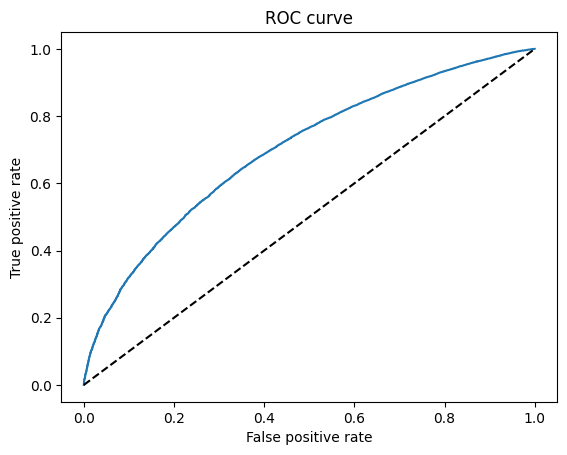

In [79]:
plt.plot(fpr, tpr)
# We plot the false positive rate along the x-axis and the true positive rate along the y-axis,
# thus plotting the ROC curve.
plt.plot(fpr, fpr, linestyle = '--', color = 'k')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('False positive rate')
# We name the x-axis "False positive rate".
plt.ylabel('True positive rate')
# We name the x-axis "True positive rate".
plt.title('ROC curve')
# We name the graph "ROC curve".
plt.savefig("../reports/figures/roc_plot.png")

In [80]:
aucroc = roc_auc_score(df_actual_predicted_probs['loan_data_target_test'],df_actual_predicted_probs['y_hat_test_proba'])

In [81]:
aucroc

0.7006936488940144

## Gini and KS coefficient

these coefficients are used to find how effectively the good and bad can be separated 

In [82]:
df_actual_predicted_probs = df_actual_predicted_probs.sort_values('y_hat_test_proba')

In [83]:
df_actual_predicted_probs = df_actual_predicted_probs.reset_index()

In [84]:
df_actual_predicted_probs['Cummilative_N_Population'] = df_actual_predicted_probs.index + 1

In [85]:
df_actual_predicted_probs['Cummilative_N_Good'] = df_actual_predicted_probs['loan_data_target_test'].cumsum()
df_actual_predicted_probs['Cummilative_N_Bad'] = df_actual_predicted_probs['Cummilative_N_Population'] - df_actual_predicted_probs['loan_data_target_test'].cumsum()

In [86]:
df_actual_predicted_probs

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cummilative_N_Population,Cummilative_N_Good,Cummilative_N_Bad
0,41663,1,0.474508,0,1,1,0
1,2808,0,0.486043,0,2,1,1
2,210472,0,0.498439,0,3,1,2
3,41549,1,0.508327,0,4,2,2
4,165242,1,0.512941,0,5,3,2
...,...,...,...,...,...,...,...
93252,239098,1,0.991225,1,93253,83063,10190
93253,242624,1,0.991306,1,93254,83064,10190
93254,256391,1,0.991484,1,93255,83065,10190
93255,261086,1,0.992376,1,93256,83066,10190


In [87]:
df_actual_predicted_probs['Cummuilative_perc_population']  = df_actual_predicted_probs['Cummilative_N_Population']/(df_actual_predicted_probs.shape[0])
df_actual_predicted_probs['Cummuilative_perc_Good']  = df_actual_predicted_probs['Cummilative_N_Good']/(df_actual_predicted_probs['loan_data_target_test'].sum())
df_actual_predicted_probs['Cummuilative_perc_Bad']  = df_actual_predicted_probs['Cummilative_N_Bad']/(df_actual_predicted_probs.shape[0] - df_actual_predicted_probs['loan_data_target_test'].sum())

In [88]:
df_actual_predicted_probs

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cummilative_N_Population,Cummilative_N_Good,Cummilative_N_Bad,Cummuilative_perc_population,Cummuilative_perc_Good,Cummuilative_perc_Bad
0,41663,1,0.474508,0,1,1,0,0.000011,0.000012,0.000000
1,2808,0,0.486043,0,2,1,1,0.000021,0.000012,0.000098
2,210472,0,0.498439,0,3,1,2,0.000032,0.000012,0.000196
3,41549,1,0.508327,0,4,2,2,0.000043,0.000024,0.000196
4,165242,1,0.512941,0,5,3,2,0.000054,0.000036,0.000196
...,...,...,...,...,...,...,...,...,...,...
93252,239098,1,0.991225,1,93253,83063,10190,0.999957,0.999952,1.000000
93253,242624,1,0.991306,1,93254,83064,10190,0.999968,0.999964,1.000000
93254,256391,1,0.991484,1,93255,83065,10190,0.999979,0.999976,1.000000
93255,261086,1,0.992376,1,93256,83066,10190,0.999989,0.999988,1.000000


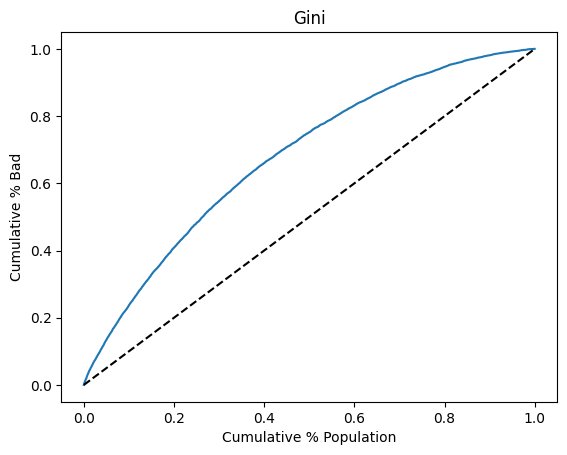

In [89]:
# Plot Gini
plt.plot(df_actual_predicted_probs['Cummuilative_perc_population'], df_actual_predicted_probs['Cummuilative_perc_Bad'])
# We plot the cumulative percentage of all along the x-axis and the cumulative percentage 'good' along the y-axis,
# thus plotting the Gini curve.
plt.plot(df_actual_predicted_probs['Cummuilative_perc_population'], df_actual_predicted_probs['Cummuilative_perc_population'], linestyle = '--', color = 'k')
# We plot a seconary diagonal line, with dashed line style and black color.
plt.xlabel('Cumulative % Population')
# We name the x-axis "Cumulative % Population".
plt.ylabel('Cumulative % Bad')
# We name the y-axis "Cumulative % Bad".
plt.title('Gini')
# We name the graph "Gini".
plt.savefig("../reports/figures/Gini.png")

In [90]:
Gini = 2*aucroc - 1

In [91]:
Gini

0.40138729778802884

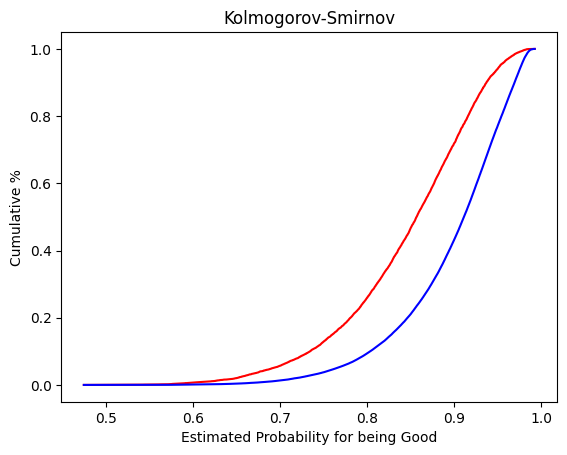

In [92]:
# Plot KS
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cummuilative_perc_Bad'], color = 'r')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'bad' along the y-axis,
# colored in red.
plt.plot(df_actual_predicted_probs['y_hat_test_proba'], df_actual_predicted_probs['Cummuilative_perc_Good'], color = 'b')
# We plot the predicted (estimated) probabilities along the x-axis and the cumulative percentage 'good' along the y-axis,
# colored in red.
plt.xlabel('Estimated Probability for being Good')
# We name the x-axis "Estimated Probability for being Good".
plt.ylabel('Cumulative %')
# We name the y-axis "Cumulative %".
plt.title('Kolmogorov-Smirnov')
# We name the graph "Kolmogorov-Smirnov".
plt.savefig("../reports/figures/Komogorov-Smirnov.png")

In [93]:
KS = max(df_actual_predicted_probs['Cummuilative_perc_Bad'] - df_actual_predicted_probs['Cummuilative_perc_Good'])
KS

0.29353618718909447

In [94]:
ref_categories = ['grade:G',
 'home_ownership:RENT_OTHER_NONE_ANY',
 'addr_state:ND_NE_IA_NV_FL_HI_AL',
 'verification_status:Verified',
 'purpose:smallBus_edu_moving_house',
 'initial_list_status:f',
 'term_int:60',
 'emp_length:0',
 'mnths_since_issue_d_date:>84',
 'int_rate:>20.281',
 'mnths_since_earlier_cr_line:<143',
 'delinq_2yrs:>=4',
 'inq_last_6mths:>6',
 'total_rev_hi_lim:<=5K',
 'annual_inc:<20k',
 'dti:>20.8',
 'mths_since_last_delinq:0-3']

In [95]:
df_ref_categories = pd.DataFrame(ref_categories,columns=['feature_names'])

In [96]:
df_ref_categories['Coefficients'] = 0
df_ref_categories['p_values'] = np.nan
df_ref_categories

,feature_names,Coefficients,p_values
0,grade:G,0,NaN
1,home_ownership:RENT_OTHER_NONE_ANY,0,NaN
2,addr_state:ND_NE_IA_NV_FL_HI_AL,0,NaN
3,verification_status:Verified,0,NaN
4,purpose:smallBus_edu_moving_house,0,NaN
5,initial_list_status:f,0,NaN
6,term_int:60,0,NaN
7,emp_length:0,0,NaN
8,mnths_since_issue_d_date:>84,0,NaN
9,int_rate:>20.281,0,NaN


In [97]:
pd.set_option('display.max_rows', None)

In [98]:
summary_table

,feature_names,Coefficients,p_values
0,Intercept,-0.237249,NaN
1,grade:A,1.014864,1.206880e-28
2,grade:B,0.817441,2.909017e-41
3,grade:C,0.628211,7.071104e-29
4,grade:D,0.447463,5.534890e-17
5,grade:E,0.282017,2.616708e-09
6,grade:F,0.099804,4.270535e-02
7,home_ownership:OWN,0.088231,1.200133e-05
8,home_ownership:MORTGAGE,0.105705,6.593884e-17
9,addr_state:NM_VA,0.042117,1.889762e-01


## Scorecard Building

scorecard helps in easy understanding of credit score and our model is build . our model job was to give the probability of default now we or the client can decide the cutoff after that they can approve loan to someone

In [100]:
df_scorecard = pd.concat([summary_table,df_ref_categories])
df_scorecard = df_scorecard.reset_index()

In [101]:
df_scorecard['Original_variable'] = df_scorecard['feature_names'].str.split(':').str[0]

In [102]:
df_scorecard

,index,feature_names,Coefficients,p_values,Original_variable
0,0,Intercept,-0.237249,NaN,Intercept
1,1,grade:A,1.014864,1.206880e-28,grade
2,2,grade:B,0.817441,2.909017e-41,grade
3,3,grade:C,0.628211,7.071104e-29,grade
4,4,grade:D,0.447463,5.534890e-17,grade
5,5,grade:E,0.282017,2.616708e-09,grade
6,6,grade:F,0.099804,4.270535e-02,grade
7,7,home_ownership:OWN,0.088231,1.200133e-05,home_ownership
8,8,home_ownership:MORTGAGE,0.105705,6.593884e-17,home_ownership
9,9,addr_state:NM_VA,0.042117,1.889762e-01,addr_state


In [103]:
min_sum_coeff = df_scorecard.groupby('Original_variable')['Coefficients'].min().sum()
min_sum_coeff

np.float64(-0.3762577175190527)

In [104]:
max_sum_coeff = df_scorecard.groupby('Original_variable')['Coefficients'].max().sum()
max_sum_coeff

np.float64(5.823096774794428)

this is the standard global range used in FICO Score 

In [105]:
max_score = 850
min_score = 300

score for every feature 

In [106]:
df_scorecard['Score_Calculation'] = df_scorecard['Coefficients']*((max_score-min_score)/(max_sum_coeff-min_sum_coeff))
df_scorecard

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation
0,0,Intercept,-0.237249,NaN,Intercept,-21.048452
1,1,grade:A,1.014864,1.206880e-28,grade,90.037588
2,2,grade:B,0.817441,2.909017e-41,grade,72.522446
3,3,grade:C,0.628211,7.071104e-29,grade,55.734180
4,4,grade:D,0.447463,5.534890e-17,grade,39.698422
5,5,grade:E,0.282017,2.616708e-09,grade,25.020268
6,6,grade:F,0.099804,4.270535e-02,grade,8.854487
7,7,home_ownership:OWN,0.088231,1.200133e-05,home_ownership,7.827796
8,8,home_ownership:MORTGAGE,0.105705,6.593884e-17,home_ownership,9.378039
9,9,addr_state:NM_VA,0.042117,1.889762e-01,addr_state,3.736536


In [107]:
df_scorecard['Score_Calculation'].sum()

np.float64(1621.315604556238)

this is for the intercept 

In [108]:
df_scorecard['Score_Calculation'][0]= ((df_scorecard['Coefficients'][0] - min_sum_coeff)/(max_sum_coeff - min_sum_coeff))*(max_score - min_score) + min_score
df_scorecard

C:\Users\TransOrg\AppData\Local\Temp\ipykernel_43076\4042615396.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Score_Calculation'][0]= ((df_scorecard['Coefficients'][0] - min_sum_coeff)/(max_sum_coeff - min_sum_coeff))*(ma

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation
0,0,Intercept,-0.237249,NaN,Intercept,312.332724
1,1,grade:A,1.014864,1.206880e-28,grade,90.037588
2,2,grade:B,0.817441,2.909017e-41,grade,72.522446
3,3,grade:C,0.628211,7.071104e-29,grade,55.734180
4,4,grade:D,0.447463,5.534890e-17,grade,39.698422
5,5,grade:E,0.282017,2.616708e-09,grade,25.020268
6,6,grade:F,0.099804,4.270535e-02,grade,8.854487
7,7,home_ownership:OWN,0.088231,1.200133e-05,home_ownership,7.827796
8,8,home_ownership:MORTGAGE,0.105705,6.593884e-17,home_ownership,9.378039
9,9,addr_state:NM_VA,0.042117,1.889762e-01,addr_state,3.736536


In [109]:
df_scorecard['Score_Preliminary'] = df_scorecard['Score_Calculation'].round()
df_scorecard

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation,Score_Preliminary
0,0,Intercept,-0.237249,NaN,Intercept,312.332724,312.0
1,1,grade:A,1.014864,1.206880e-28,grade,90.037588,90.0
2,2,grade:B,0.817441,2.909017e-41,grade,72.522446,73.0
3,3,grade:C,0.628211,7.071104e-29,grade,55.734180,56.0
4,4,grade:D,0.447463,5.534890e-17,grade,39.698422,40.0
5,5,grade:E,0.282017,2.616708e-09,grade,25.020268,25.0
6,6,grade:F,0.099804,4.270535e-02,grade,8.854487,9.0
7,7,home_ownership:OWN,0.088231,1.200133e-05,home_ownership,7.827796,8.0
8,8,home_ownership:MORTGAGE,0.105705,6.593884e-17,home_ownership,9.378039,9.0
9,9,addr_state:NM_VA,0.042117,1.889762e-01,addr_state,3.736536,4.0


here you can see it is coming 299 instead of 300 its because of the round of we did ( so I did some changes not worth explaining)

In [110]:
df_scorecard.groupby('Original_variable')['Score_Preliminary'].min().sum()

np.float64(299.0)

In [111]:
df_scorecard['difference'] = np.abs(df_scorecard['Score_Calculation'] - df_scorecard['Score_Preliminary'])
df_scorecard.sort_values(['Original_variable','Score_Calculation','difference'])

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation,Score_Preliminary,difference
0,0,Intercept,-0.237249,NaN,Intercept,312.332724,312.0,0.332724
86,2,addr_state:ND_NE_IA_NV_FL_HI_AL,0.000000,NaN,addr_state,0.000000,0.0,0.000000
9,9,addr_state:NM_VA,0.042117,1.889762e-01,addr_state,3.736536,4.0,0.263464
10,10,addr_state:NY,0.055952,2.089104e-02,addr_state,4.963982,5.0,0.036018
11,11,addr_state:OK_TN_MO_LA_MD_NC,0.056007,1.556269e-02,addr_state,4.968915,5.0,0.031085
12,12,addr_state:CA,0.064222,2.438942e-03,addr_state,5.697734,6.0,0.302266
13,13,addr_state:UT_KY_AZ_NJ,0.077962,1.751615e-03,addr_state,6.916672,7.0,0.083328
15,15,addr_state:RI_MA_DE_SD_IN,0.102696,5.792175e-04,addr_state,9.111096,9.0,0.111096
14,14,addr_state:AR_MI_PA_OH_MN,0.133889,2.686025e-09,addr_state,11.878448,12.0,0.121552
16,16,addr_state:GA_WA_OR,0.182958,6.627539e-12,addr_state,16.231844,16.0,0.231844


In [112]:
df_scorecard['Final_score'] = df_scorecard['Score_Preliminary']
df_scorecard['Final_score'][75] = 31

C:\Users\TransOrg\AppData\Local\Temp\ipykernel_43076\476043261.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Final_score'][75] = 31
C:\Users\TransOrg\AppData\Local\Temp\ipykernel_43076\476043261.py:2: SettingWithCopyWarni

In [113]:
df_scorecard['Final_score'][54] = -1

C:\Users\TransOrg\AppData\Local\Temp\ipykernel_43076\3551037417.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_scorecard['Final_score'][54] = -1
C:\Users\TransOrg\AppData\Local\Temp\ipykernel_43076\3551037417.py:1: SettingWithCopyWar

In [114]:
df_scorecard.groupby('Original_variable')['Final_score'].min().sum()

np.float64(300.0)

In [115]:
df_scorecard

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation,Score_Preliminary,difference,Final_score
0,0,Intercept,-0.237249,NaN,Intercept,312.332724,312.0,0.332724,312.0
1,1,grade:A,1.014864,1.206880e-28,grade,90.037588,90.0,0.037588,90.0
2,2,grade:B,0.817441,2.909017e-41,grade,72.522446,73.0,0.477554,73.0
3,3,grade:C,0.628211,7.071104e-29,grade,55.734180,56.0,0.265820,56.0
4,4,grade:D,0.447463,5.534890e-17,grade,39.698422,40.0,0.301578,40.0
5,5,grade:E,0.282017,2.616708e-09,grade,25.020268,25.0,0.020268,25.0
6,6,grade:F,0.099804,4.270535e-02,grade,8.854487,9.0,0.145513,9.0
7,7,home_ownership:OWN,0.088231,1.200133e-05,home_ownership,7.827796,8.0,0.172204,8.0
8,8,home_ownership:MORTGAGE,0.105705,6.593884e-17,home_ownership,9.378039,9.0,0.378039,9.0
9,9,addr_state:NM_VA,0.042117,1.889762e-01,addr_state,3.736536,4.0,0.263464,4.0


In [116]:
inputs_train_with_ref_cat.drop(['open_acc:0', 'open_acc:1-3', 'open_acc:4-12', 'open_acc:13-22', 'open_acc:>=23','pub_rec:0-2', 
                                'pub_rec:3-4', 'pub_rec:>=5', 'total_acc:<=27', 'total_acc:28-51', 'total_acc:>=52', 
                                'acc_now_delinq:0', 'acc_now_delinq:>=1','mths_since_last_record:Missing', 'mths_since_last_record:0-2', 
                                'mths_since_last_record:3-20', 'mths_since_last_record:21-31', 'mths_since_last_record:32-80', 
                                'mths_since_last_record:81-86', 'mths_since_last_record:>86'],axis = 1,inplace = True)

In [117]:
inputs_test_with_ref_cat = loan_data_test_input.loc[:,['grade:A',
 'grade:B',
 'grade:C',
 'grade:D',
 'grade:E',
 'grade:F',
 'grade:G',
 'home_ownership:RENT_OTHER_NONE_ANY',
 'home_ownership:OWN',
 'home_ownership:MORTGAGE',
 'addr_state:ND_NE_IA_NV_FL_HI_AL',
 'addr_state:NM_VA',
 'addr_state:NY',
 'addr_state:OK_TN_MO_LA_MD_NC',
 'addr_state:CA',
 'addr_state:UT_KY_AZ_NJ',
 'addr_state:AR_MI_PA_OH_MN',
 'addr_state:RI_MA_DE_SD_IN',
 'addr_state:GA_WA_OR',
 'addr_state:WI_MT',
 'addr_state:TX',
 'addr_state:IL_CT',
 'addr_state:KS_SC_CO_VT_AK_MS',
 'addr_state:WV_NH_WY_DC_ME_ID',
 'verification_status:Not Verified',
 'verification_status:Source Verified',
 'verification_status:Verified',
 'purpose:smallBus_edu_moving_house',
 'purpose:other_renewable_medical_wedding',
 'purpose:wedding_vacation',
 'purpose:homeImprovement_majorPurchase_car',
 'purpose:credit_card',
 'initial_list_status:f',
 'initial_list_status:w',
 'term_int:36',
 'term_int:60',
 'emp_length:0',
 'emp_length:1',
 'emp_length:2-4',
 'emp_length:5-6',
 'emp_length:7-9',
 'emp_length:10',
 'mnths_since_issue_d_date:<39',
 'mnths_since_issue_d_date:39-41',
 'mnths_since_issue_d_date:42-42',
 'mnths_since_issue_d_date:43-50',
 'mnths_since_issue_d_date:51-53',
 'mnths_since_issue_d_date:54-64',
 'mnths_since_issue_d_date:65-84',
 'mnths_since_issue_d_date:>84',
 'int_rate:<9.548',
 'int_rate:9.548-12.025',
 'int_rate:12.025-15.74',
 'int_rate:15.74-20.281',
 'int_rate:>20.281',
 'mnths_since_earlier_cr_line:<143',
 'mnths_since_earlier_cr_line:144-167',
 'mnths_since_earlier_cr_line:168-250',
 'mnths_since_earlier_cr_line:251-274',
 'mnths_since_earlier_cr_line:>275',
 'delinq_2yrs:0',
 'delinq_2yrs:1-3',
 'delinq_2yrs:>=4',
 'inq_last_6mths:0',
 'inq_last_6mths:1-2',
 'inq_last_6mths:3-6',
 'inq_last_6mths:>6',
 'total_rev_hi_lim:<=5K',
 'total_rev_hi_lim:5K-10K',
 'total_rev_hi_lim:10K-20K',
 'total_rev_hi_lim:20K-30K',
 'total_rev_hi_lim:30K-40K',
 'total_rev_hi_lim:40K-55K',
 'total_rev_hi_lim:55K-95K',
 'total_rev_hi_lim:>95K',
 'annual_inc:<20k',
 'annual_inc:20k-30k',
 'annual_inc:30k-40k',
 'annual_inc:40k-50k',
 'annual_inc:50k-60k',
 'annual_inc:60k-70k',
 'annual_inc:70k-80k',
 'annual_inc:80k-90k',
 'annual_inc:90k-100k',
 'annual_inc:100k-120k',
 'annual_inc:120k-140k',
 'annual_inc:>140k',
 'dti:<=1.6',
 'dti:1.6-4',
 'dti:4-5.6',
 'dti:5.6-8',
 'dti:8-15.2',
 'dti:15.2-16.8',
 'dti:16.8-20.8',
 'dti:>20.8',
 'mths_since_last_deling:Missing',
 'mths_since_last_delinq:0-3',
 'mths_since_last_delinq:4-30',
 'mths_since_last_delinq:31-56',
 'mths_since_last_delinq:>=57'
]]

In [118]:
inputs_test_with_ref_cat.shape

(93257, 100)

In [119]:
inputs_test_with_ref_cat.to_csv('inputs_test_with_ref_cat.csv')

In [120]:
inputs_test.shape

(93257, 83)

In [121]:
pd.reset_option('display.max_rows')

In [122]:
inputs_test.shape

(93257, 83)

In [123]:
inputs_test_with_ref_cat.shape

(93257, 100)

In [124]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat

In [125]:
inputs_test_with_ref_cat_w_intercept.insert(0,'Intercept',1)

In [126]:
inputs_test_with_ref_cat_w_intercept  = inputs_test_with_ref_cat_w_intercept.astype(int)

In [127]:
inputs_test_with_ref_cat_w_intercept

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,grade:G,home_ownership:RENT_OTHER_NONE_ANY,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:ND_NE_IA_NV_FL_HI_AL,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,verification_status:Verified,purpose:smallBus_edu_moving_house,purpose:other_renewable_medical_wedding,purpose:wedding_vacation,purpose:homeImprovement_majorPurchase_car,purpose:credit_card,initial_list_status:f,initial_list_status:w,term_int:36,term_int:60,emp_length:0,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mnths_since_issue_d_date:<39,mnths_since_issue_d_date:39-41,mnths_since_issue_d_date:42-42,mnths_since_issue_d_date:43-50,mnths_since_issue_d_date:51-53,mnths_since_issue_d_date:54-64,mnths_since_issue_d_date:65-84,mnths_since_issue_d_date:>84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,int_rate:>20.281,mnths_since_earlier_cr_line:<143,mnths_since_earlier_cr_line:144-167,mnths_since_earlier_cr_line:168-250,mnths_since_earlier_cr_line:251-274,mnths_since_earlier_cr_line:>275,delinq_2yrs:0,delinq_2yrs:1-3,delinq_2yrs:>=4,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,inq_last_6mths:>6,total_rev_hi_lim:<=5K,total_rev_hi_lim:5K-10K,total_rev_hi_lim:10K-20K,total_rev_hi_lim:20K-30K,total_rev_hi_lim:30K-40K,total_rev_hi_lim:40K-55K,total_rev_hi_lim:55K-95K,total_rev_hi_lim:>95K,annual_inc:<20k,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.6,dti:1.6-4,dti:4-5.6,dti:5.6-8,dti:8-15.2,dti:15.2-16.8,dti:16.8-20.8,dti:>20.8,mths_since_last_deling:Missing,mths_since_last_delinq:0-3,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57
362514,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
288564,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0
213591,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0
263083,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0
165001,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1,0,1,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
296284,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0

In [128]:
inputs_test_with_ref_cat_w_intercept = inputs_test_with_ref_cat_w_intercept[df_scorecard['feature_names'].values]

In [157]:
inputs_test_with_ref_cat_w_intercept

,Intercept,grade:A,grade:B,grade:C,grade:D,grade:E,grade:F,home_ownership:OWN,home_ownership:MORTGAGE,addr_state:NM_VA,addr_state:NY,addr_state:OK_TN_MO_LA_MD_NC,addr_state:CA,addr_state:UT_KY_AZ_NJ,addr_state:AR_MI_PA_OH_MN,addr_state:RI_MA_DE_SD_IN,addr_state:GA_WA_OR,addr_state:WI_MT,addr_state:TX,addr_state:IL_CT,addr_state:KS_SC_CO_VT_AK_MS,addr_state:WV_NH_WY_DC_ME_ID,verification_status:Not Verified,verification_status:Source Verified,purpose:other_renewable_medical_wedding,purpose:wedding_vacation,purpose:homeImprovement_majorPurchase_car,purpose:credit_card,initial_list_status:w,term_int:36,emp_length:1,emp_length:2-4,emp_length:5-6,emp_length:7-9,emp_length:10,mnths_since_issue_d_date:<39,mnths_since_issue_d_date:39-41,mnths_since_issue_d_date:42-42,mnths_since_issue_d_date:43-50,mnths_since_issue_d_date:51-53,mnths_since_issue_d_date:54-64,mnths_since_issue_d_date:65-84,int_rate:<9.548,int_rate:9.548-12.025,int_rate:12.025-15.74,int_rate:15.74-20.281,mnths_since_earlier_cr_line:144-167,mnths_since_earlier_cr_line:168-250,mnths_since_earlier_cr_line:251-274,mnths_since_earlier_cr_line:>275,delinq_2yrs:0,delinq_2yrs:1-3,inq_last_6mths:0,inq_last_6mths:1-2,inq_last_6mths:3-6,total_rev_hi_lim:5K-10K,total_rev_hi_lim:10K-20K,total_rev_hi_lim:20K-30K,total_rev_hi_lim:30K-40K,total_rev_hi_lim:40K-55K,total_rev_hi_lim:55K-95K,total_rev_hi_lim:>95K,annual_inc:20k-30k,annual_inc:30k-40k,annual_inc:40k-50k,annual_inc:50k-60k,annual_inc:60k-70k,annual_inc:70k-80k,annual_inc:80k-90k,annual_inc:90k-100k,annual_inc:100k-120k,annual_inc:120k-140k,annual_inc:>140k,dti:<=1.6,dti:1.6-4,dti:4-5.6,dti:5.6-8,dti:8-15.2,dti:15.2-16.8,dti:16.8-20.8,mths_since_last_deling:Missing,mths_since_last_delinq:4-30,mths_since_last_delinq:31-56,mths_since_last_delinq:>=57,grade:G,home_ownership:RENT_OTHER_NONE_ANY,addr_state:ND_NE_IA_NV_FL_HI_AL,verification_status:Verified,purpose:smallBus_edu_moving_house,initial_list_status:f,term_int:60,emp_length:0,mnths_since_issue_d_date:>84,int_rate:>20.281,mnths_since_earlier_cr_line:<143,delinq_2yrs:>=4,inq_last_6mths:>6,total_rev_hi_lim:<=5K,annual_inc:<20k,dti:>20.8,mths_since_last_delinq:0-3
362514,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,1,1,1,0,0,0,0,0,0,0,0,0
288564,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,1,1
213591,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
263083,1,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
165001,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0
296284,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,1,0,0,1

In [137]:
scorecard_scores = df_scorecard['Final_score']

In [138]:
scorecard_scores.shape

(101,)

In [139]:
inputs_test_with_ref_cat_w_intercept.shape

(93257, 101)

In [140]:
scorecard_scores = scorecard_scores.values.reshape(101,1)

this is y_score which is the score of every user in the test dataset 

In [141]:
y_score = inputs_test_with_ref_cat_w_intercept.dot(scorecard_scores)

In [148]:
y_score.head()

,0
362514,567.0
288564,503.0
213591,528.0
263083,598.0
165001,653.0


In [150]:
y_score.shape

(93257, 1)

df_scorecard helps use find that how much each feature will contribute in the total score 

In [151]:
df_scorecard.head()

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation,Score_Preliminary,difference,Final_score
0,0,Intercept,-0.237249,NaN,Intercept,312.332724,312.0,0.332724,312.0
1,1,grade:A,1.014864,1.206880e-28,grade,90.037588,90.0,0.037588,90.0
2,2,grade:B,0.817441,2.909017e-41,grade,72.522446,73.0,0.477554,73.0
3,3,grade:C,0.628211,7.071104e-29,grade,55.734180,56.0,0.265820,56.0
4,4,grade:D,0.447463,5.534890e-17,grade,39.698422,40.0,0.301578,40.0


In [152]:
df_scorecard

,index,feature_names,Coefficients,p_values,Original_variable,Score_Calculation,Score_Preliminary,difference,Final_score
0,0,Intercept,-0.237249,NaN,Intercept,312.332724,312.0,0.332724,312.0
1,1,grade:A,1.014864,1.206880e-28,grade,90.037588,90.0,0.037588,90.0
2,2,grade:B,0.817441,2.909017e-41,grade,72.522446,73.0,0.477554,73.0
3,3,grade:C,0.628211,7.071104e-29,grade,55.734180,56.0,0.265820,56.0
4,4,grade:D,0.447463,5.534890e-17,grade,39.698422,40.0,0.301578,40.0
...,...,...,...,...,...,...,...,...,...
96,12,inq_last_6mths:>6,0.000000,NaN,inq_last_6mths,0.000000,0.0,0.000000,0.0
97,13,total_rev_hi_lim:<=5K,0.000000,NaN,total_rev_hi_lim,0.000000,0.0,0.000000,0.0
98,14,annual_inc:<20k,0.000000,NaN,annual_inc,0.000000,0.0,0.000000,0.0
99,15,dti:>20.8,0.000000,NaN,dti,0.000000,0.0,0.000000,0.0


In [153]:
customer_wise_score = pd.concat([inputs_test_with_ref_cat_w_intercept,y_score],axis = 1)

made a new table customer_wise_score

In [154]:
customer_wise_score.rename(columns={0: 'Customer_final_credit_score'}, inplace=True) 

In [155]:
customer_wise_score['Customer_final_credit_score'].max()

np.float64(785.0)

## From credit score to PD

now here we are converting the credit score into PD to reject or accept because PD is more accurate then Credit score so basically this is PD for every user 

In [138]:
sum_coeff_from_score = ((y_score - min_score)/(max_score-min_score))*(max_sum_coeff -  min_sum_coeff) + min_sum_coeff
sum_coeff_from_score

,0
362514,2.633247
288564,1.911868
213591,2.193657
263083,2.982665
165001,3.602601
...,...
115,2.126027
296284,3.557514
61777,3.861846
91763,3.377170


In [139]:
y_hat_proba_from_score = (np.exp(sum_coeff_from_score)/(1+np.exp(sum_coeff_from_score)))
y_hat_proba_from_score

,0
362514,0.932971
288564,0.871229
213591,0.899678
263083,0.951785
165001,0.973470
...,...
115,0.893407
296284,0.972281
61777,0.979404
91763,0.966983


it is not similar to the actual probabilit we calculated from our model because of the little round of we did

In [140]:
y_hat_test_proba

array([0.91904374, 0.8461454 , 0.87900924, ..., 0.9748602 , 0.96016035,
       0.95131506], shape=(93257,))

## Setting Cutoffs

this is the table we are making for different threshold what is the Approval rate adn rejection rate

In [141]:
df_cutoff = pd.concat([pd.DataFrame(thresholds),pd.DataFrame(fpr),pd.DataFrame(tpr)],axis = 1)

In [142]:
df_cutoff.columns = ['Thresholds','FPR','TPR']

In [143]:
df_cutoff

,Thresholds,FPR,TPR
0,inf,0.000000,0.000000
1,0.992390,0.000000,0.000012
2,0.990833,0.000000,0.000084
3,0.990832,0.000098,0.000084
4,0.990626,0.000098,0.000120
...,...,...,...
17255,0.529811,0.999607,0.999940
17256,0.526180,0.999804,0.999940
17257,0.508327,0.999804,0.999988
17258,0.486043,1.000000,0.999988


In [144]:
df_cutoff['Thresholds'][0] = 1 - 1/np.pow(10,16)

C:\Users\TransOrg\AppData\Local\Temp\ipykernel_55068\1013697322.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoff['Thresholds'][0] = 1 - 1/np.pow(10,16)


In [145]:
df_cutoff

,Thresholds,FPR,TPR
0,1.000000,0.000000,0.000000
1,0.992390,0.000000,0.000012
2,0.990833,0.000000,0.000084
3,0.990832,0.000098,0.000084
4,0.990626,0.000098,0.000120
...,...,...,...
17255,0.529811,0.999607,0.999940
17256,0.526180,0.999804,0.999940
17257,0.508327,0.999804,0.999988
17258,0.486043,1.000000,0.999988


In [146]:
df_cutoff['Score'] = ((np.log(df_cutoff['Thresholds']/(1-df_cutoff['Thresholds'])) - min_sum_coeff)*((max_score - min_score)/(max_sum_coeff - min_sum_coeff)) + min_score)

In [147]:
df_cutoff['Score'][0] = max_score

C:\Users\TransOrg\AppData\Local\Temp\ipykernel_55068\2359892504.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df_cutoff['Score'][0] = max_score


In [148]:
df_cutoff

,Thresholds,FPR,TPR,Score
0,1.000000,0.000000,0.000000,850.000000
1,0.992390,0.000000,0.000012,765.494995
2,0.990833,0.000000,0.000084,748.843113
3,0.990832,0.000098,0.000084,748.833062
4,0.990626,0.000098,0.000120,746.842780
...,...,...,...,...
17255,0.529811,0.999607,0.999940,343.972805
17256,0.526180,0.999804,0.999940,342.680373
17257,0.508327,0.999804,0.999988,336.336364
17258,0.486043,1.000000,0.999988,328.426933


In [149]:
df_actual_predicted_probs

,index,loan_data_target_test,y_hat_test_proba,y_hat_test,Cummilative_N_Population,Cummilative_N_Good,Cummilative_N_Bad,Cummuilative_perc_population,Cummuilative_perc_Good,Cummuilative_perc_Bad
0,41663,1,0.474508,0,1,1,0,0.000011,0.000012,0.000000
1,2808,0,0.486043,0,2,1,1,0.000021,0.000012,0.000098
2,210472,0,0.498439,0,3,1,2,0.000032,0.000012,0.000196
3,41549,1,0.508327,0,4,2,2,0.000043,0.000024,0.000196
4,165242,1,0.512941,0,5,3,2,0.000054,0.000036,0.000196
...,...,...,...,...,...,...,...,...,...,...
93252,239098,1,0.991225,1,93253,83063,10190,0.999957,0.999952,1.000000
93253,242624,1,0.991306,1,93254,83064,10190,0.999968,0.999964,1.000000
93254,256391,1,0.991484,1,93255,83065,10190,0.999979,0.999976,1.000000
93255,261086,1,0.992376,1,93256,83066,10190,0.999989,0.999988,1.000000


In [150]:
def n_approved(p):
    return np.where(df_actual_predicted_probs['y_hat_test_proba']>=p,1,0).sum()

In [151]:
df_cutoff['N_approved'] = df_cutoff['Thresholds'].apply(n_approved)

In [152]:
df_cutoff['N_rejected'] = df_actual_predicted_probs.shape[0] - df_cutoff['Thresholds'].apply(n_approved)

In [153]:
df_cutoff['Approval_Rate'] = df_cutoff['N_approved']/df_actual_predicted_probs.shape[0]
df_cutoff['Rejection_Rate'] = df_cutoff['N_rejected']/df_actual_predicted_probs.shape[0]

final df_cutoff table

In [154]:
df_cutoff

,Thresholds,FPR,TPR,Score,N_approved,N_rejected,Approval_Rate,Rejection_Rate
0,1.000000,0.000000,0.000000,850.000000,0,93257,0.000000,1.000000
1,0.992390,0.000000,0.000012,765.494995,1,93256,0.000011,0.999989
2,0.990833,0.000000,0.000084,748.843113,7,93250,0.000075,0.999925
3,0.990832,0.000098,0.000084,748.833062,8,93249,0.000086,0.999914
4,0.990626,0.000098,0.000120,746.842780,11,93246,0.000118,0.999882
...,...,...,...,...,...,...,...,...
17255,0.529811,0.999607,0.999940,343.972805,93248,9,0.999903,0.000097
17256,0.526180,0.999804,0.999940,342.680373,93250,7,0.999925,0.000075
17257,0.508327,0.999804,0.999988,336.336364,93254,3,0.999968,0.000032
17258,0.486043,1.000000,0.999988,328.426933,93256,1,0.999989,0.000011


In [155]:
inputs_train_with_ref_cat.to_csv('../data/processed/train/inputs_train_with_ref_cat.csv')

In [156]:
df_scorecard.to_csv('../reports/csv/df_scorecard.csv')

In [157]:
df_cutoff

,Thresholds,FPR,TPR,Score,N_approved,N_rejected,Approval_Rate,Rejection_Rate
0,1.000000,0.000000,0.000000,850.000000,0,93257,0.000000,1.000000
1,0.992390,0.000000,0.000012,765.494995,1,93256,0.000011,0.999989
2,0.990833,0.000000,0.000084,748.843113,7,93250,0.000075,0.999925
3,0.990832,0.000098,0.000084,748.833062,8,93249,0.000086,0.999914
4,0.990626,0.000098,0.000120,746.842780,11,93246,0.000118,0.999882
...,...,...,...,...,...,...,...,...
17255,0.529811,0.999607,0.999940,343.972805,93248,9,0.999903,0.000097
17256,0.526180,0.999804,0.999940,342.680373,93250,7,0.999925,0.000075
17257,0.508327,0.999804,0.999988,336.336364,93254,3,0.999968,0.000032
17258,0.486043,1.000000,0.999988,328.426933,93256,1,0.999989,0.000011


In [158]:
with open("model2_with_p_values.pkl", "wb") as f:
    pickle.dump(model2, f)

I have saved all important files and my final model in csv and pickle format respectively

In [159]:
df_cutoff.to_csv('../reports/csv/df_cutoff.csv')